# Ground State Preparation by the Interaction-Based Algorithm
### Fermi-Hubbard model
## 1. Overview
This notebook implements a small-scale interaction-based system-bath algorithm for preparing the ground state of a Fermi-Hubbard Hamiltonian $H$. 
We refer to the quantum system of interest as the **system**, and the ancillary qubits as the **bath**. The algorithm thermalizes or cools the system through a repeated-interaction framework.

The goal is to drive the system state toward the ground state. At the $n$-th iteration, a fresh bath qubit is prepared, the joint system-bath state evolves under a time-dependent Hamiltonian, and the bath qubit is then traced out. Averaging over the sampled system operator $A$, bath frequency $\omega$, and random sign $s$, one idealized step is
$$
\rho_{n+1}
=
\Phi(\rho_{n})
=
\mathbb{E}_{A,\omega,s}
\operatorname{Tr}_E
\left[
U_\Gamma(T)
\left(\rho_{n}\otimes \rho_E\right)
U_\Gamma^{\dagger}(T)
\right].
$$
where $\rho_n$ is the system state at the $n$-th iteration, $\rho_E$ is the initial bath state, and $\operatorname{Tr}_E$ denotes the partial trace over the environment. The unitary $U_\Gamma(T)$ is generated by a time-dependent system-bath Hamiltonian. $\mathbb{E}_{A,\omega,s}$ denotes the average over the sampled system operator $A$, frequency $\omega$, and sign $s$.


One iteration consists of the following steps:

1. Initialize a fresh bath ancilla in the ground state $|0\rangle$.
2. Evolve the joint system-bath state for time $T$ under the time-dependent Hamiltonian $H_\Gamma(t)$.
3. Trace out the bath ancilla.
4. Reset the bath and repeat the procedure for the next iteration.

### Imports and numerical conventions

The implementation is organized into two main modules:

- `hamiltonians.py` provides routines for constructing the Fermi-Hubbard Hamiltonian and the system coupling operators.
- `channels.py` provides routines for constructing and applying the repeated-interaction channel.

We use `quimb` for spin and tensor-product operators, `numpy`/`scipy` for dense linear algebra, and a few functions from the local files `hamiltonians.py` and `channels.py`.

The functions used below are:

- `hubbard_spinful_fermi`: builds the Fermi-Hubbard Hamiltonian.
- `jw_fermion_ops_flat`: returns Jordan-Wigner fermionic creation/annihilation operators.
- `_expm_from_eigh`: constructs a matrix exponential from an eigendecomposition.
- `f_gaussian`: evaluates the Gaussian pulse $f(t)$.
- `suzuki_trotter_vbasis`: applies the Trotterized joint system-bath evolution.
- `trace_out_last_qubit`: removes the last bath qubit.

In [2]:
import quimb as qu
import numpy as np

import scipy.sparse as sp
from scipy.linalg import expm
from scipy.sparse import coo_matrix
from numpy.polynomial.hermite import hermgauss
from numpy import linalg as LA
import random

import matplotlib as mpl # noqa
import matplotlib.pyplot as plt # noqa
from tqdm import tqdm

from hamiltonians import hubbard_spinful_fermi,jw_fermion_ops_flat
from channels import _expm_from_eigh,_sym_herm,f_gaussian,trace_out_last_qubit,suzuki_trotter_vbasis

import warnings
import os
def short_warning(message, category, filename, lineno, line=None):
    return f"{os.path.basename(filename)}:{lineno}: {category.__name__}: {message}\n"
warnings.formatwarning = short_warning

# quimb operator construction options
op_kws = {'sparse': True, 'stype': 'coo'}
ikron_kws = {'sparse': True, 'stype': 'coo',
             'coo_build': True, 'ownership': None}

## 2. Model and Parameters
### One-Step Hamiltonian

For a fixed sampled bath frequency $\omega$, system operator $A$, and sign $s\in\{+1,-1\}$, the joint system-bath Hamiltonian is

$$
H_{\Gamma}(t)
=
H \otimes \mathbb{I}_E
+
\mathbb{I}_S \otimes H_E(\omega)
+
\Gamma f(t)
\left(
sA \otimes B
+
sA^{\dagger} \otimes B^{\dagger}
\right).
$$

Here $H$ is the system Hamiltonian. $H_E(\omega)$ is the bath Hamiltonian with frequency $\omega$.  $\Gamma$ is the coupling strength and $f(t)$ is the filter function. The interaction term includes the system and bath operators $A$ and $B_E$.
- The system operator $A$ is sampled from the set $\mathcal{A}$.
- The frequency $\omega$ is sampled from the distribution $g(\omega)$.
- The sign $s$ is sampled uniformly from $\{\pm 1\}$. 

Repeated applications of $\Phi_\Gamma$ drive the system toward the desired ground state.

Denote the free system-bath Hamiltonian as
$$
H_0
=
H \otimes \mathbb{I}_E
+
\mathbb{I}_S \otimes H_E(\omega),
$$
and the interaction Hamiltonian as
$$
H_I
=
s(A \otimes B)
+
s(A \otimes B)^\dagger,
\qquad s \in \{+1,-1\}.
$$
The joint Hamiltonian becomes 
$$ H_{\Gamma}(t) = H_0 + \Gamma f(t)H_I .$$

### State vector evolution and Trotter splitting
In one step, we first sample a bath frequency $\omega$, choose a system operator $A$, and choose a random sign $s$. For the state vector, it satisfies the Schr\"odinger equation  
$$ \partial_t |\psi(t)\rangle = -i (H_0 + \Gamma f(t) H_I) |\psi(t)\rangle  $$
Since the evolution operator is the time-ordered exponential, 
$$|\psi(t)\rangle = \mathcal{T}
\exp\left(
-i\int_{-T}^{T}
\left(H_0+\Gamma f(t)H_I\right)\,dt
\right)
|\psi(-T)\rangle.$$
It is approximated by the Suzuki-Trotter splitting. On the time point $t_n$, 
$$
|\psi_{n+1}\rangle
\approx
e^{-iH_0\Delta t/2}
e^{-i\Gamma f(t_n)H_I\Delta t}
e^{-iH_0\Delta t/2}
|\psi_n\rangle.
$$

Finally, a partial trace would generally return a density matrix,

$$
\rho_{n+1}
=
\operatorname{Tr}_E
\left[
|\psi_{n+1}\rangle\langle\psi_{n+1}|
\right].
$$

This notebook follows the vector-based convention implemented in `trace_out_last_qubit`. 


### Parameters

We work with a two-site spinful Fermi-Hubbard model. The system Hilbert space dimension is

$$
d_S=4^N=2^{2N}.
$$

- The bath is a single qubit with $$H_E(\omega) = -\frac{\omega}{2} Z,\quad
  B = \frac{X+iY}{2}. $$

- The filter function $ f(t) = \frac{1}{(2\pi)^{1/4}\sigma} \exp\left(-\frac{t^2}{4\sigma^2}\right).$
- The frequency is sampled from $g(\omega)=\frac{1}{5}\mathbf{1}_{[0,5]}(\omega)$.
- The initial bath state is set to the target temperature. Namely, for thermal-state preparation,
  $\rho_E=
  \frac{
    e^{-\beta H_E(\omega)}
  }{
    \operatorname{Tr}\left(e^{-\beta H_E(\omega)}\right)
  }.
  $
  For ground-state preparation,
  $
  \rho_E = |0\rangle\langle 0|.
  $
- The one step simulation time $T = 5\sigma$. 
- The parameter $\alpha = \Gamma/\sqrt{\sigma}$.

In [3]:
N=2               #number of sites in the physical model
dsys = 2 ** (2*N) # system dimension
sigma = 4         #width of the Gaussian pulse
Ss = 5 * sigma    #Time window for one interaction step: [-Ss, Ss].
dTime = 0.1       #Trotter time step size.
alpha_list = np.array([1]) / (sigma**0.5) # choice of alpha
BB = 5            #maximum bath frequency
Nstep = 2000      #number of iterations

## 3. Construct the Hamiltonian and the target state
### Fermi-Hubbard Hamiltonian
The system Hamiltonian and operators are constructed using functions from hamiltonians.py. 
$$
H = -t\sum_{j=1}^{L-1} \sum_{\sigma\in\{\uparrow,\downarrow\}} c_{j,\sigma}^\dagger c_{j+1,\sigma}+U\sum_{j=1}^L (n_{j,\uparrow}-\frac{1}{2})(n_{j,\downarrow}-\frac{1}{2})\,.
$$

The system operators are sampled from the fermionic ladder operators produced by `jw_fermion_ops_flat`.

In [4]:
# fermi hubbard model
Hamsys = hubbard_spinful_fermi(N, t = 1.0, U=-4.0, op_kws=op_kws, ikron_kws=ikron_kws)
Hamsys = Hamsys.toarray()
# System operators used in the system-bath interaction.
As_op_array = jw_fermion_ops_flat(N) #sample from fermionic operators

### Diagonalize the system Hamiltonian
We diagonalize the system Hamiltonian $H$. This gives the exact ground state energy and the system energy eigenbasis.
The initial state is chosen to be the highest energy eigenstate.

In [5]:
Hamsys_original = Hamsys.copy()   # The original system Hamiltonian is stored in Hamsys_original.
eigenvalues, eigenvectors = LA.eigh(Hamsys)
ground_energy = eigenvalues[0]
ground_state = eigenvectors[:, 0] # The lowest energy eigenstate.
phi_ini = eigenvectors[:, -1]     # Start from the highest energy eigenstate.
print("Ground state energy of the system Hamiltonian:", ground_energy)

# Convenience embedding of H_S into the system-bath Hilbert space.
Hamsys = np.kron(Hamsys, np.eye(2))

Ground state energy of the system Hamiltonian: -8.0


### Free system-bath eigenbasis
For each sampled $\omega$,  the free system-bath Hamiltonian

$$
H_0 := H \otimes \mathbb{I}_E + \mathbb{I}_S \otimes H_E(\omega).
$$

Since the bath eigenvectors are $|0\rangle$ and $|1\rangle$, the free system-bath eigenvectors are the product states

$$
|E_k\rangle \otimes |0\rangle,
\qquad
|E_k\rangle \otimes |1\rangle,
$$

where $|E_k\rangle$ is an eigenvector of the system Hamiltonian $H$. The matrix `Q_se` stores these product eigenvectors as columns. It is used to construct the free half-step propagator in the Suzuki-Trotter splitting. For each new sampled $\omega$, we only need to update the corresponding eigenvalues
$
E_k-\frac{\omega}{2},
E_k+\frac{\omega}{2}.
$

In [6]:
eigvec_bath_0 = np.array([1,0])
eigvec_bath_1 = np.array([0,1])

Q_se = np.array([np.kron(eigenvectors[:, k], eigvec_bath)
        for k in range(len(eigenvalues))
        for eigvec_bath in (eigvec_bath_0, eigvec_bath_1)])
Q_se = Q_se.T

## 4. Run one stochastic trajectory
We now simulate the repeated-interaction dynamics for a single coupling value. At each iteration, the code:

1. samples $\omega\sim g(\omega)$,
2. forms the free eigenvalues $w_{SE}$,
3. samples a fermionic system operator $A$, `A = random.choice(As_op_array)`,
4. constructs the Hermitian interaction $H_I$,
5. applies the Trotterized joint evolution to $|\phi_n\rangle\otimes |0\rangle_E$,
6. removes the bath qubit using `trace_out_last_qubit`, and
7. records the system energy $\langle \phi_n|H_S|\phi_n\rangle$.

To implement the unitary evolution of the free system-bath Hamiltonian and the interaction Hamiltonian, we use their eigendecompositions, `_expm_from_eigh`. For example, if $H_0 = Q \operatorname{diag}(\omega) Q^{\dagger}$, then the half step propagator is 
$$
\exp(-i H_0 \Delta t/2) = Q \operatorname{diag} (e^{-i\omega\Delta/2}) Q^\dagger.
$$
The interaction propagator is constructed in the same way after diagonalizing the interaction Hamiltonian.

In [7]:
idx = 0
alpha = alpha_list[idx]

energy = np.zeros((Nstep+1,len(alpha_list)))
energy[0,idx] = np.real(phi_ini.conj() @ Hamsys_original @ phi_ini)

phi_list = phi_ini.copy()

phi_bath = np.array([1,0])

# precompute the Gaussian pulse 
nsub  = 2*round(Ss/dTime) + 1
tgrid = (np.arange(nsub) * dTime) - Ss
fvals = np.asarray([f_gaussian(t, sigma) for t in tgrid], dtype=float)

# bath operator in the interaction term, B_E
B = qu.spin_operator('x', **op_kws)+1j*qu.spin_operator('y', **op_kws)

# fix all random seeds for reproducibility 
np.random.seed(50)
random.seed(50)

for i in tqdm(range(Nstep)):
    # Sample bath frequency
    omega = random.uniform(0, BB)
    # Eigenvalues of the free system-bath Hamiltonian
    w_se =  np.array([eigenvalues[k]+eig_bath for k in range(len(eigenvectors))
            for eig_bath in (-omega/2, omega/2)])
    
    # Randomly choose a system operator
    A = random.choice(As_op_array)
    
    # Construct a Hermitian system-bath interaction
    sign_random = (-1)**(random.randint(0,1))
    
    interact = sign_random*qu.kron(A,qu.ikron(B, (2,) * 1, 0, **ikron_kws))
    interact += interact.conj().T
    
    # Diagonalize the interaction Hamiltonian
    wv, Qv = np.linalg.eigh(interact.toarray())
    
    # Free half-step propagator
    U0_half  = _expm_from_eigh(Q_se, w_se, factor=(-1j * dTime / 2.0))
    
    # Prepare the joint system-bath state
    phi_temp = np.kron(phi_list, phi_bath)
    
    # Evolve the joint state and trace out the bath qubit
    phi_list = trace_out_last_qubit(suzuki_trotter_vbasis(phi_temp, fvals, alpha, dTime, Qv, wv, U0_half))
    
    # Record system energy
    energy[i+1,idx] = np.real(phi_list.conj().T @ Hamsys_original @ phi_list)

  0%|          | 0/2000 [00:00<?, ?it/s]channels.py:27: RuntimeWarning: divide by zero encountered in matmul
channels.py:27: RuntimeWarning: overflow encountered in matmul
channels.py:27: RuntimeWarning: invalid value encountered in matmul
channels.py:358: RuntimeWarning: divide by zero encountered in matmul
channels.py:358: RuntimeWarning: overflow encountered in matmul
channels.py:358: RuntimeWarning: invalid value encountered in matmul
channels.py:359: RuntimeWarning: divide by zero encountered in matmul
channels.py:359: RuntimeWarning: overflow encountered in matmul
channels.py:359: RuntimeWarning: invalid value encountered in matmul
channels.py:360: RuntimeWarning: divide by zero encountered in matmul
channels.py:360: RuntimeWarning: overflow encountered in matmul
channels.py:360: RuntimeWarning: invalid value encountered in matmul
channels.py:363: RuntimeWarning: divide by zero encountered in matmul
channels.py:363: RuntimeWarning: overflow encountered in matmul
channels.py:363: 

### Plot the energy decay

The main diagnostic is the energy expectation value

$$
E_n=\langle \phi_n|H_S|\phi_n\rangle.
$$

For this small example, exact diagonalization gives the reference ground-state energy $E_0$, shown as the dashed line. A successful cooling trajectory should move the energy downward toward this reference value.

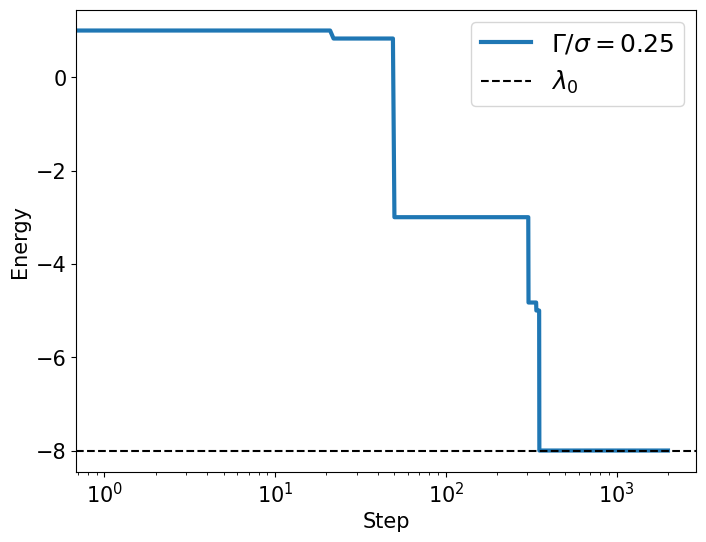

In [8]:
plt.figure(figsize=(8,6))
linestyles = ["-", "--", "-.", ":", "-", "--"]
for idx in range(len(alpha_list)):
    ratio = alpha_list[idx] / np.sqrt(sigma)
    plt.plot(energy[0:Nstep+1,idx], linewidth=3, label=fr'$\Gamma/\sigma = {ratio:.2f}$', linestyle=linestyles[idx])

plt.axhline(y=ground_energy, color='k', linestyle='--', label=r'$\lambda_0$')
plt.xlabel(r'Step', fontsize=15)
plt.ylabel(r'Energy', fontsize=15)
plt.legend(fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xscale('log', base=10)
plt.savefig("figures/Fermi_Hubbard_energy_2.pdf", bbox_inches="tight", dpi=300)
plt.show()

## 5. The properties of the channel
We can also construct the averaged quantum channel and analyze its fixed point.

In the following codes, we compute two channel-level quantities:

- the fidelity between the channel fixed point and the exact ground state;
- the spectral gap of the averaged channel.


In [12]:
from channels import construct_unified_channel,analyze_fixed_point
beta = np.inf
sigma_list= [sigma, 2*sigma, 4*sigma]
alpha_list = np.array([1, 0.5, 0.25, 0.1, 0.05, 0.01]) / (sigma**0.5)
fidelity_list = np.zeros((len(alpha_list), len(sigma_list)))
spectral_gap_list = np.zeros((len(alpha_list), len(sigma_list)))
for idx, alpha in enumerate(alpha_list):
    for sidx, sigma_t in enumerate(sigma_list):
        print(f"\n=== Channel Validation for alpha={alpha:.2e}, sigma={sigma_t:.2e} ===")
        channel_unified = construct_unified_channel(Hamsys_base=Hamsys_original, As_ops=As_op_array, alpha=alpha, beta=beta, sigma=sigma_t, dTime=dTime)
        rho_fixed_unified, fidelity_list[idx,sidx], spectral_gap_list[idx,sidx] = analyze_fixed_point(channel_unified, "Unified Protocol", ground_state)


=== Channel Validation for alpha=5.00e-01, sigma=4.00e+00 ===
Constructing unified channel ( β = inf)...


Bath frequencies:   0%|          | 0/50 [00:00<?, ?it/s]channels.py:27: RuntimeWarning: divide by zero encountered in matmul
channels.py:27: RuntimeWarning: overflow encountered in matmul
channels.py:27: RuntimeWarning: invalid value encountered in matmul
channels.py:120: RuntimeWarning: divide by zero encountered in matmul
channels.py:120: RuntimeWarning: overflow encountered in matmul
channels.py:120: RuntimeWarning: invalid value encountered in matmul
channels.py:121: RuntimeWarning: divide by zero encountered in matmul
channels.py:121: RuntimeWarning: overflow encountered in matmul
channels.py:121: RuntimeWarning: invalid value encountered in matmul
channels.py:130: RuntimeWarning: divide by zero encountered in matmul
channels.py:130: RuntimeWarning: overflow encountered in matmul
channels.py:130: RuntimeWarning: invalid value encountered in matmul
Bath frequencies: 100%|██████████| 50/50 [00:11<00:00,  4.44it/s]



=== Unified Protocol Fixed Point Analysis ===

=== Channel Validation for alpha=5.00e-01, sigma=8.00e+00 ===
Constructing unified channel ( β = inf)...


Bath frequencies: 100%|██████████| 50/50 [00:16<00:00,  3.03it/s]



=== Unified Protocol Fixed Point Analysis ===

=== Channel Validation for alpha=5.00e-01, sigma=1.60e+01 ===
Constructing unified channel ( β = inf)...


...


=== Unified Protocol Fixed Point Analysis ===

=== Channel Validation for alpha=5.00e-03, sigma=8.00e+00 ===
Constructing unified channel ( β = inf)...


Bath frequencies: 100%|██████████| 50/50 [00:16<00:00,  3.02it/s]



=== Unified Protocol Fixed Point Analysis ===

=== Channel Validation for alpha=5.00e-03, sigma=1.60e+01 ===
Constructing unified channel ( β = inf)...


Bath frequencies: 100%|██████████| 50/50 [00:26<00:00,  1.86it/s]


=== Unified Protocol Fixed Point Analysis ===


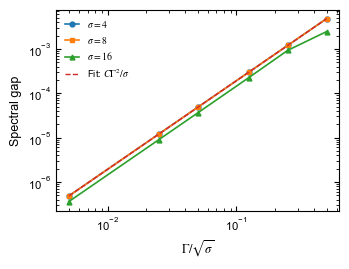

In [13]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def model(alpha, C):
    return C*alpha**2

# Fit the data
popt, pcov = curve_fit(model, alpha_list, spectral_gap_list[:,0])
C_fit = popt[0]
# Generate smooth curve for plotting
alpha_fit = np.linspace(min(alpha_list), max(alpha_list), 200)
gap_fit = model(alpha_fit, C_fit)

markers = ['o', 's', '^', 'D', 'v', 'x', '*', 'p', 'h']

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "stix",
    "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(3.35, 2.55))  

for idx, sigma_t in enumerate(sigma_list):
    plt.plot(alpha_list, spectral_gap_list[:, idx],linewidth=1.2,
        label=rf'$\sigma={sigma_t}$', marker=markers[idx], markersize=3.5)

plt.plot(alpha_fit, gap_fit, '--', linewidth=1.0, label=rf'Fit: $C\Gamma^2/\sigma$' )

plt.xlabel(r'$\Gamma/\sqrt{\sigma}$', fontsize=9)
plt.ylabel(r'Spectral gap', fontsize=9)

plt.xscale('log', base=10)
plt.yscale('log', base=10)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.legend(fontsize=7, loc='upper left', frameon=False, handlelength=1.5)
plt.grid(False)

plt.tight_layout(pad=0.2)

plt.savefig( "figures/Hubbard_2_channel_spectral_gap.pdf", format="pdf", bbox_inches="tight", dpi=300)

plt.show()